### Mount Drive.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Copy BIRD databases from Drive to local Colab disk.

In [ ]:
# import shutil
# shutil.rmtree("/content/MINIDEV", ignore_errors=True)

In [24]:
import zipfile
from pathlib import Path

DRIVE_BIRD_ZIP = Path("/content/drive/MyDrive/MINIDEV.zip")
LOCAL_BIRD_ROOT = Path("/content/MINIDEV")

if not DRIVE_BIRD_ZIP.exists():
    print(f"MINIDEV.zip not found on Drive at: {DRIVE_BIRD_ZIP}")
elif LOCAL_BIRD_ROOT.exists():
    print("Already extracted locally this session, skipping.")
else:
    print("MINIDEV.zip found on Drive. Extracting to local disk...")
    with zipfile.ZipFile(DRIVE_BIRD_ZIP) as z:
        z.extractall("/content")   # <-- extract to /content, NOT into LOCAL_BIRD_ROOT
    print("Extraction complete.")

expected = ["mini_dev_sqlite.json", "mini_dev_sqlite_gold.sql", "dev_databases"]
missing = [name for name in expected if not (LOCAL_BIRD_ROOT / name).exists()]
if missing:
    print(f"WARNING: still missing: {missing}")
else:
    print(f"Verified: {LOCAL_BIRD_ROOT} contains {expected}")

MINIDEV.zip found on Drive. Extracting to local disk...
Extraction complete.
Verified: /content/MINIDEV contains ['mini_dev_sqlite.json', 'mini_dev_sqlite_gold.sql', 'dev_databases']


In [ ]:
# !pip install -q gdown

In [ ]:
# pip uninstall -y torchao
# pip install --no-cache-dir "torchao>=0.16.0"

### Gold SQL Validation Check

In [ ]:
# !cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/src/scripts/prepare_bird_eval.py \
#     --bird-root /content/MINIDEV \
#     --output-dir evidence/milestone5/bird

3/500 examples excluded from accuracy computation due to non-executable gold SQL.

### Run smoke test

In [ ]:
!pip install torchao==0.18.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 96.2 MB/s eta 0:00:00


In [ ]:
!python -c "import torchao; print(torchao.__version__)"

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
0.18.0


In [ ]:
# !cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/evaluate_text2sql_models.py \
#   --config configs/text2sql_eval_models.json \
#   --manifest models/download_manifest.json \
#   --data evidence/milestone5/bird/bird_eval.jsonl \
#   --model qwen3-4b-instruct-2507 \
#   --adapter-dir /content/drive/MyDrive/final_checkpoint_375_adapter \
#   --adapter-label milestone4_frozen \
#   --cache-dir /content/drive/MyDrive/huggingface-cache \
#   --batch-size 8 \
#   --limit 300 \
#   --output-dir evidence/milestone5/evaluation_ddl

### Final Full Evaluation

In [ ]:
# !cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/evaluate_text2sql_models.py \
#   --config configs/text2sql_eval_models.json \
#   --manifest models/download_manifest.json \
#   --data evidence/milestone5/bird/bird_eval.jsonl \
#   --model qwen3-4b-instruct-2507 \
#   --adapter-dir /content/drive/MyDrive/final_checkpoint_375_adapter \
#   --adapter-label milestone4_frozen \
#   --cache-dir /content/drive/MyDrive/huggingface-cache \
#   --batch-size 8 \
#   --output-dir evidence/milestone5/evaluation_ddl

2026-08-11 13:59:18,692 | INFO | Starting on NVIDIA L4 (22.03 GiB), torch=2.11.0+cu128 transformers=5.13.1
2026-08-11 13:59:20,387 | INFO | milestone4_frozen: 500 completed, 0 pending
config.json: 100% 727/727 [00:00<00:00, 3.76MB/s]
tokenizer_config.json: 100% 9.38k/9.38k [00:00<00:00, 34.3MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 109MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 118MB/s]

tokenizer.json: downloading bytes:   0% 0.00/11.4M [00:00<?, ?B/s]
tokenizer.json: downloading bytes: 100% 3.40M/3.40M [00:01<00:00, 2.33MB/s,  330kB/s  ]
tokenizer.json: reconstructing file: 100% 11.4M/11.4M [00:01<00:00, 7.81MB/s, 1.11MB/s  ]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu

###

### Check gold execution status

In [ ]:
import json

with open("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/evaluation_ddl/milestone4_frozen/predictions.jsonl") as f:
    rows = [json.loads(l) for l in f]

print(f"{len(rows)}/500 completed")

from collections import Counter
print("gold_execution_status:", Counter(r["gold_execution_status"] for r in rows))

500/500 completed
gold_execution_status: Counter({'ok': 500})


In [5]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/src/scripts/analyze_eval_results.py \
  --predictions evidence/milestone5/evaluation_ddl/milestone4_frozen/predictions.jsonl

Total examples: 500
gold_execution_status: {'ok': 500}
prediction_execution_status: {'error': 116, 'ok': 383, 'timeout': 1}

Execution accuracy
Over ALL 500 examples:                16.8%
Over 500 examples w/ valid gold:  16.8%
Excluded (gold failed to execute):    0


### Error Analysis

In [6]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/error_taxonomy_analysis.py \
  --predictions evidence/milestone5/evaluation_ddl/milestone4_frozen/predictions.jsonl \
  --examples-per-category 3 \
  --output-json evidence/milestone5/evaluation_ddl/error_taxonomy_summary.json

Total predictions analyzed: 500

ERROR TAXONOMY
  semantic_mismatch         299  ( 59.8%)
  correct                    84  ( 16.8%)
  hallucinated_column        66  ( 13.2%)
  syntax_error               38  (  7.6%)
  other_execution_error      10  (  2.0%)
  hallucinated_table          3  (  0.6%)

TOP HALLUCINATED COLUMNS (model referenced, doesn't exist)
  T1.age                           6 occurrences
  T1.name                          3 occurrences
  T2.A1                            3 occurrences
  T2.T                             2 occurrences
  T                                2 occurrences
  A1                               2 occurrences
  T1.Views                         2 occurrences
  YEAR                             1 occurrences
  Segment                          1 occurrences
  segment                          1 occurrences

TOP HALLUCINATED TABLES
  expense_budget                   1 occurrences
  accidents                        1 occurrences
  crime                    

In [ ]:
# ============================================================
# Milestone 5 -- Error Analysis Charts (dynamic version)
# ============================================================
# Cell 1: paste this whole block once to define the function.
# Cell 2 (separate): call plot_milestone5_charts() for each run.
#
# BIRD accuracy is read DIRECTLY from the taxonomy JSON file every time
# -- never passed in as a hardcoded number -- so the chart can never
# silently show a stale/wrong accuracy that's out of sync with the
# actual results file it's plotting from.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

COLOR_CORRECT = "#2E7D32"
COLOR_ERROR = "#C62828"
COLOR_NEUTRAL = "#1565C0"
COLOR_ACCENT = "#EF6C00"

CATEGORY_COLORS = {
    "correct": COLOR_CORRECT,
    "semantic_mismatch": "#EF6C00",
    "hallucinated_column": "#C62828",
    "syntax_error": "#8E24AA",
    "other_execution_error": "#546E7A",
    "hallucinated_table": "#AD1457",
}
CATEGORY_LABELS = {
    "correct": "Correct",
    "semantic_mismatch": "Semantic Mismatch\n(executes, wrong result)",
    "hallucinated_column": "Hallucinated Column",
    "syntax_error": "Syntax Error",
    "other_execution_error": "Other Execution Error",
    "hallucinated_table": "Hallucinated Table",
}
FEATURE_LABELS = {
    "has_join": "Any JOIN",
    "multiple_joins": "Multiple JOINs (2+)",
    "has_group_by": "GROUP BY",
    "has_subquery": "Subquery",
    "join_and_subquery": "JOIN + Subquery",
    "long_sql": "Long SQL (>31 tokens)",
}


def plot_milestone5_charts(
    taxonomy_path,
    output_dir,
    run_label,
    spider_accuracy_pct,
    macsql_metrics_path=None,
    macsql_label=None,
):
    """
    Generates and displays all Milestone 5 error-analysis charts for ONE
    evaluation run (e.g. "DDL" or "M-Schema").

    BIRD accuracy is read directly from taxonomy_path's own
    error_taxonomy_pct["correct"] field -- there is no bird_accuracy_pct
    parameter, so it is impossible for the chart to show a value that
    doesn't match the actual results file.

    spider_accuracy_pct is still a parameter since Spider's result lives
    in a separate report this function doesn't read.

    run_label is used in chart titles/filenames so outputs from different
    calls (e.g. DDL vs M-Schema) don't overwrite each other.
    """
    taxonomy_path = Path(taxonomy_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    with open(taxonomy_path, encoding="utf-8") as f:
        taxonomy = json.load(f)

    bird_accuracy_pct = taxonomy["error_taxonomy_pct"]["correct"]
    n_examples = taxonomy["total_examples"]
    slug = run_label.lower().replace(" ", "_")

    print(f"[{run_label}] source: {taxonomy_path}")
    print(f"[{run_label}] n={n_examples}  accuracy={bird_accuracy_pct:.1f}%")

    # ---- Chart 1: Error taxonomy ----
    counts = taxonomy["error_taxonomy_counts"]
    pct = taxonomy["error_taxonomy_pct"]
    order = ["correct"] + sorted((k for k in counts if k != "correct"), key=lambda k: counts[k], reverse=True)
    labels = [CATEGORY_LABELS.get(k, k) for k in order]
    values = [pct[k] for k in order]
    colors = [CATEGORY_COLORS.get(k, COLOR_NEUTRAL) for k in order]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(labels, values, color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Percentage of examples (%)")
    ax.set_title(f"Error Taxonomy -- {run_label} (n={n_examples})")
    ax.set_xlim(0, max(values) * 1.15)
    for bar, k in zip(bars, order):
        ax.text(bar.get_width() + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.1f}%  (n={counts[k]})", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(output_dir / f"error_taxonomy_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ---- Chart 2: Feature-conditioned accuracy ----
    fca = taxonomy["feature_conditioned_accuracy"]
    features = list(fca.keys())
    f_labels = [FEATURE_LABELS.get(f, f) for f in features]
    acc_with = [fca[f]["accuracy_with_feature"] * 100 for f in features]
    n_with = [fca[f]["n_with_feature"] for f in features]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(f_labels, acc_with, color=COLOR_ACCENT)
    ax.axhline(bird_accuracy_pct, color=COLOR_NEUTRAL, linestyle="--", linewidth=1.5,
               label=f"Overall accuracy ({bird_accuracy_pct:.1f}%)")
    ax.set_ylabel("Execution accuracy (%)")
    ax.set_title(f"Accuracy Conditioned on SQL Structural Features -- {run_label}")
    ax.legend(loc="upper right")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    for bar, n in zip(bars, n_with):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, max(acc_with + [bird_accuracy_pct]) * 1.3)
    plt.tight_layout()
    plt.savefig(output_dir / f"feature_conditioned_accuracy_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ---- Chart 3: Accuracy by join count ----
    by_join = taxonomy["accuracy_by_join_count"]
    counts_sorted = sorted(by_join.items(), key=lambda kv: int(kv[0]))
    x_labels = [f"{k} JOIN{'s' if k != '1' else ''}" for k, _ in counts_sorted]
    y_values = [v * 100 for _, v in counts_sorted]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(x_labels, y_values, marker="o", color=COLOR_ERROR, linewidth=2, markersize=8)
    ax.fill_between(range(len(x_labels)), y_values, alpha=0.15, color=COLOR_ERROR)
    ax.set_ylabel("Execution accuracy (%)")
    ax.set_title(f"Accuracy vs. Number of JOINs -- {run_label}")
    ax.set_ylim(0, max(y_values) * 1.3 if max(y_values) > 0 else 10)
    for x, y in zip(x_labels, y_values):
        ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(output_dir / f"accuracy_by_join_count_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ---- Chart 4: Hallucinated names ----
    top_cols = taxonomy.get("top_hallucinated_columns", [])[:10]
    top_tables = taxonomy.get("top_hallucinated_tables", [])[:10]

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    if top_cols:
        names = [c[0] for c in top_cols][::-1]
        vals = [c[1] for c in top_cols][::-1]
        axes[0].barh(names, vals, color=COLOR_ERROR)
        axes[0].set_title(f"Top Hallucinated Columns -- {run_label}")
        axes[0].set_xlabel("Occurrences")
    if top_tables:
        names = [t[0] for t in top_tables][::-1]
        vals = [t[1] for t in top_tables][::-1]
        axes[1].barh(names, vals, color="#AD1457")
        axes[1].set_title(f"Top Hallucinated Tables -- {run_label}")
        axes[1].set_xlabel("Occurrences")
    plt.tight_layout()
    plt.savefig(output_dir / f"hallucinated_names_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ---- Chart 5: Strict vs MAC-SQL (optional, still reads its own file dynamically) ----
    if macsql_metrics_path and macsql_label and Path(macsql_metrics_path).exists():
        with open(macsql_metrics_path, encoding="utf-8") as f:
            macsql_metrics = json.load(f)
        m = macsql_metrics[macsql_label]
        strict_pct = m["strict_execution"]["pct"]
        macsql_pct = m["macsql_execution"]["pct"]
        promoted = m["column_permutation_or_distinct_promotions"]["count"]
        n = m["examples"]

        fig, ax = plt.subplots(figsize=(5.5, 5))
        bars = ax.bar(["Strict\nExecution Accuracy", "MAC-SQL/FINER\nCompatible Accuracy"],
                       [strict_pct, macsql_pct], color=[COLOR_NEUTRAL, COLOR_ACCENT], width=0.55)
        ax.set_ylabel("Execution accuracy (%)")
        ax.set_title(f"Scoring Method Comparison -- {run_label} (n={n})")
        ax.set_ylim(0, max(strict_pct, macsql_pct) * 1.4)
        for bar, val in zip(bars, [strict_pct, macsql_pct]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
        ax.annotate(f"+{promoted} examples ({promoted/n*100:.1f}%)\npromoted by column\npermutation tolerance",
                    xy=(1, macsql_pct), xytext=(1.15, macsql_pct * 0.6), fontsize=8, ha="left",
                    arrowprops=dict(arrowstyle="->", color="gray"))
        plt.tight_layout()
        plt.savefig(output_dir / f"strict_vs_macsql_{slug}.png", dpi=150, bbox_inches="tight")
        plt.show()

        # Sanity check: strict accuracy from macsql_metrics should match
        # the taxonomy's own "correct" pct -- if not, the two files are
        # out of sync (e.g. one regenerated, the other not).
        if abs(strict_pct - bird_accuracy_pct) > 0.15:
            print(f"[{run_label}] WARNING: strict accuracy in macsql metrics ({strict_pct:.1f}%) "
                  f"doesn't match taxonomy accuracy ({bird_accuracy_pct:.1f}%) -- "
                  f"one of these files is stale, regenerate both from the same predictions.jsonl.")
    else:
        print(f"[{run_label}] skipped strict_vs_macsql chart (no macsql metrics given)")

    # ---- Chart 6: Spider vs BIRD ----
    fig, ax = plt.subplots(figsize=(6, 5.5))
    bars = ax.bar(
        ["Spider Validation\n(in-domain, used\nduring development)", f"BIRD Mini-Dev\n(cross-benchmark,\n{run_label} prompt)"],
        [spider_accuracy_pct, bird_accuracy_pct], color=[COLOR_NEUTRAL, COLOR_ERROR], width=0.55,
    )
    ax.set_ylabel("Execution accuracy (%)")
    ax.set_title(f"In-Domain vs. Cross-Benchmark Generalization -- {run_label}")
    ax.set_ylim(0, max(spider_accuracy_pct, bird_accuracy_pct) * 1.25)
    for bar, val in zip(bars, [spider_accuracy_pct, bird_accuracy_pct]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(spider_accuracy_pct, bird_accuracy_pct) * 0.02,
                f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold")
    drop = spider_accuracy_pct - bird_accuracy_pct
    ax.annotate(f"-{drop:.1f} pts", xy=(0.5, (spider_accuracy_pct + bird_accuracy_pct) / 2),
                ha="center", fontsize=10, color=COLOR_ERROR, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_dir / f"spider_vs_bird_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"[{run_label}] all charts saved to: {output_dir}\n")

    return bird_accuracy_pct

In [ ]:
# plot_milestone5_charts(
#     taxonomy_path="evidence/milestone5/error_taxonomy_summary.json",
#     output_dir="evidence/milestone5/figures",
#     run_label="DDL",
#     spider_accuracy_pct=78.6,
#     macsql_metrics_path="evidence/milestone5/scoring_ddl/metrics.json",
#     macsql_label="milestone4_frozen",
# )


### MSchema Eval

In [ ]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/prepare_bird_mschema_eval.py \
    --bird-root /content/MINIDEV \
    --output-dir evidence/milestone5/bird \
    --render-script-dir src/scripts

BIRD root: /content/MINIDEV
Output directory: /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/bird
Prepared 50/500  (gold ok=50, error=0, ddl_fallback_rows=0)
Prepared 100/500  (gold ok=100, error=0, ddl_fallback_rows=0)
Prepared 150/500  (gold ok=150, error=0, ddl_fallback_rows=22)
Prepared 200/500  (gold ok=200, error=0, ddl_fallback_rows=51)
Prepared 250/500  (gold ok=250, error=0, ddl_fallback_rows=51)
Prepared 300/500  (gold ok=300, error=0, ddl_fallback_rows=51)
Prepared 350/500  (gold ok=350, error=0, ddl_fallback_rows=51)
Prepared 400/500  (gold ok=400, error=0, ddl_fallback_rows=51)
Prepared 450/500  (gold ok=450, error=0, ddl_fallback_rows=51)
Prepared 500/500  (gold ok=500, error=0, ddl_fallback_rows=51)

Created: /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/bird/bird_eval_mschema.jsonl
Gold SQL validation: {'ok': 500, 'error': 0}
Databases using M-Schema: 10
Databases using DDL fallback (oversized): ['european_football_

Only 1 of 11 databases needed the DDL fallback — european_football_2 (51 rows, ~10% of the dataset). This makes sense: it's known for having a large, wide schema (lots of player/match statistics columns), so it's a very plausible candidate for exceeding the 10,000-char M-Schema threshold. Interesting that card_games/codebase_community — the ones we flagged early on as "expensive" for query execution — apparently rendered under the threshold; being slow to query (due to row count/joins) is a different thing from having a large schema (many columns), so this isn't contradictory.

This is genuinely useful, citable data for your report: "10 of 11 BIRD databases used the native M-Schema training format; european_football_2 (51/500 examples) exceeded the 10,000-character threshold and fell back to plain DDL, mirroring the exact fallback behavior used during Milestone 4 training for oversized Spider databases." That's a precise, defensible methodology note.

In [ ]:
# !cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/evaluate_text2sql_models.py \
#   --config configs/text2sql_eval_models.json \
#   --manifest models/download_manifest.json \
#   --data evidence/milestone5/bird/bird_eval_mschema.jsonl \
#   --model qwen3-4b-instruct-2507 \
#   --adapter-dir /content/drive/MyDrive/final_checkpoint_375_adapter \
#   --adapter-label milestone4_frozen \
#   --cache-dir /content/drive/MyDrive/huggingface-cache \
#   --batch-size 8 \
#   --output-dir evidence/milestone5/evaluation_mschema

2026-08-11 14:58:48,939 | INFO | Starting on NVIDIA L4 (22.03 GiB), torch=2.11.0+cu128 transformers=5.13.1
2026-08-11 14:58:48,952 | INFO | milestone4_frozen: 30 completed, 470 pending
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading weights: 100% 398/398 [00:04<00:00, 80.68it/s]
2026-08-11 14:59:00,924 | INFO | Loaded PEFT adapter /content/drive/MyDrive/final_checkpoint_375_adapter on pinned base cdbee75f17c01a7cc42f958dc650907174af0554
2026-08-11 14:59:00,934 | INFO | milestone4_frozen loaded in 12.0s with sdpa attention; CUDA={'allocated_gib': 7.615, 'reser

In [ ]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/analyze_eval_results.py \
  --predictions evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl

Total examples: 500
gold_execution_status: {'ok': 500}
prediction_execution_status: {'error': 96, 'ok': 403, 'too_many_rows': 1}

Execution accuracy
Over ALL 500 examples:                25.8%
Over 500 examples w/ valid gold:  25.8%
Excluded (gold failed to execute):    0


In [7]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/error_taxonomy_analysis.py \
  --predictions evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl \
  --examples-per-category 3 \
  --output-json evidence/milestone5/evaluation_mschema/error_taxonomy_summary_mschema.json

Total predictions analyzed: 500

ERROR TAXONOMY
  semantic_mismatch         274  ( 54.8%)
  correct                   129  ( 25.8%)
  hallucinated_column        60  ( 12.0%)
  syntax_error               27  (  5.4%)
  other_execution_error      10  (  2.0%)

TOP HALLUCINATED COLUMNS (model referenced, doesn't exist)
  T1.age                           5 occurrences
  T2.T                             3 occurrences
  T1.count                         2 occurrences
  creationdate                     2 occurrences
  T1.year                          1 occurrences
  segment                          1 occurrences
  Segment                          1 occurrences
  date                             1 occurrences
  consumption                      1 occurrences
  T2.Consumption                   1 occurrences

TOP HALLUCINATED TABLES

FEATURE-CONDITIONED ACCURACY (gold SQL structure)
  feature                  n   accuracy   vs. rest
  has_join               407     24.8%   (without: 30.1%, n=93)
 

### Mschema mac-sql scoring

In [ ]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/score_predictions_macsql.py \
  --predictions milestone4_frozen_mschema=evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl \
  --validation evidence/milestone5/bird/bird_eval_mschema.jsonl \
  --project-root . \
  --output-dir evidence/milestone5/scoring_mschema

{
  "milestone4_frozen_mschema": {
    "by_complexity": {
      "unknown": {
        "examples": 500,
        "macsql": 143,
        "macsql_pct": 28.6,
        "strict": 129,
        "strict_pct": 25.8
      }
    },
    "column_permutation_or_distinct_promotions": {
      "count": 19,
      "pct": 3.8
    },
    "examples": 500,
    "macsql_execution": {
      "count": 143,
      "pct": 28.6
    },
    "prediction_statuses": {
      "error": 96,
      "ok": 403,
      "too_many_rows": 1
    },
    "source": "/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl",
    "strict_execution": {
      "count": 129,
      "pct": 25.8
    }
  }
}


In [ ]:
# plot_milestone5_charts(
#     taxonomy_path="evidence/milestone5/error_taxonomy_summary_mschema.json",
#     output_dir="evidence/milestone5/figures_mschema",
#     run_label="M-Schema",
#     spider_accuracy_pct=78.6,
#     macsql_metrics_path="evidence/milestone5/scoring_mschema/metrics.json",
#     macsql_label="milestone4_frozen_mschema",
# )

In [8]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/repair_hallucinated_columns.py \
  --predictions evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl \
  --bird-eval evidence/milestone5/bird/bird_eval_mschema.jsonl \
  --output evidence/milestone5/evaluation_mschema/hallucinated_column_repair_report.json

Found 60 hallucinated-column errors to attempt repair on.

REPAIR RESULTS
Total hallucinated-column errors:        60
Confident single-candidate repair found:  6  (10.0%)
Repaired query executes successfully:     4  (6.7%)
Repaired query MATCHES GOLD:               0  (0.0%)

Sample repairs:
  id=6  rewrote T2.Consumption -> T1.Consumption  executes=True  matches_gold=False
  id=71  rewrote T3.department -> T1.department  executes=False  matches_gold=False
  id=329  rewrote T2.viewcount -> T1.viewcount  executes=True  matches_gold=False
  id=337  rewrote T1.Views -> T2.Views  executes=False  matches_gold=False
  id=454  rewrote T1.cds -> T2.cds  executes=True  matches_gold=False

Full report written to: evidence/milestone5/evaluation_mschema/hallucinated_column_repair_report.json


A post-hoc deterministic repair was attempted on all 60 hallucinated-column errors: only 6 (10%) had an unambiguous single-candidate fix (most involve genuinely ambiguous column names or missing joins, not simple misattribution), and of those, zero repaired queries matched gold after execution. This indicates hallucinated-column errors are rarely isolated mistakes — the same underlying reasoning failure that misattributes a column typically also produces incorrect query logic elsewhere, meaning simple post-hoc SQL repair is not a viable mitigation for this error class without addressing the model's underlying schema-linking and reasoning limitations directly.

In [ ]:
!pip install -U bitsandbytes --quiet
!python -c "import bitsandbytes; print(bitsandbytes.__version__)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 61.1 MB/s eta 0:00:00
0.50.0


In [ ]:
!pip install bitsandbytes==0.48.1 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 42.0 MB/s eta 0:00:00


### Robustness Test

In [ ]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/test_robustness_prompts.py \
  --eval-script-dir src/scripts \
  --database /content/MINIDEV/dev_databases/debit_card_specializing/debit_card_specializing.sqlite \
  --db-id debit_card_specializing \
  --adapter-dir /content/drive/MyDrive/final_checkpoint_375_adapter \
  --output evidence/milestone5/robustness_test_report.json

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading model + adapter...
Loading weights:   0% 1/398 [00:00<01:18,  5.04it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100% 398/398 [00:02<00:00, 164.64it/s]
Model loaded.

[1/18] (invalid_table) 'List all employees hired after 2015.'
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed i

### Schema linking

In [25]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/schema_linking_precision.py \
  --predictions evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl \
  --bird-eval evidence/milestone5/bird/bird_eval_mschema.jsonl \
  --output evidence/milestone5/evaluation_mschema/schema_linking_precision.json

SCHEMA-LINKING PRECISION
Total predictions:            500
Parseable (syntax valid):     473  (94.6%)
Skipped (syntax error):       27

Table-reference precision:    100.0%  (1029/1029 references)
Column-reference precision:   82.8%  (2466/2977 references)

Examples with ALL references grounded (fully correct schema-linking): 173/473  (36.6% of parseable predictions)

--- Precision by prediction correctness ---
  Correct predictions (n=129): table precision=100.0%  column precision=82.2%
  Incorrect predictions (n=344): table precision=100.0%  column precision=83.1%

Full report written to: evidence/milestone5/evaluation_mschema/schema_linking_precision.json


**Table precision: 100.0% (1029/1029)** — checkpoint 375 **never once** referenced a table that doesn't exist, across all 500 predictions. This is a striking confirmation of what the error taxonomy already showed (0.0% hallucinated_table failures under M-Schema) — but at a much more granular level: not just "no failures were caused by table hallucination," but literally *every single table name the model ever generated* was real.

**Column precision: 82.8% (2466/2977)** — noticeably lower. About 1 in 6 column references across all predictions point to a nonexistent column. This is higher than the 12.0% *failure* rate for hallucinated columns, which makes sense: a single query can reference several columns, and it only takes **one** bad reference to fail the whole query — so the failure rate undercounts how often hallucinated references actually occur.

**Fully-grounded rate: 36.6%** — only about a third of syntactically valid queries have *zero* hallucinated references anywhere in them. (One honest caveat worth noting: this may slightly undercount true grounding, since query-local aliases — e.g. `SELECT x AS total ... ORDER BY total` — could get flagged as "not in schema" even though they're valid references to the query's own computed column, not real hallucinations. Worth mentioning as a limitation if you use this number.)

**The most interesting finding: column precision is nearly identical for correct (82.2%) vs. incorrect (83.1%) predictions.** This is a genuinely useful negative result — it shows that **getting schema references right doesn't predict getting the final answer right**. The model can reference entirely real, valid columns and still construct wrong logic. This directly reinforces your report's core existing finding: errors are dominated by *semantic/logic* mistakes (54.8%), not schema-grounding failures — this metric provides independent, reference-level confirmation of that same conclusion.

### Eval MSchema + Evidence

In [ ]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/prepare_bird_mschema_eval.py \
    --bird-root /content/MINIDEV \
    --output-dir evidence/milestone5/bird \
    --render-script-dir src/scripts \
    --include-evidence

BIRD root: /content/MINIDEV
Output directory: /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/bird
Prepared 50/500  (gold ok=50, error=0, ddl_fallback_rows=0)
Prepared 100/500  (gold ok=100, error=0, ddl_fallback_rows=0)
Prepared 150/500  (gold ok=150, error=0, ddl_fallback_rows=22)
Prepared 200/500  (gold ok=200, error=0, ddl_fallback_rows=51)
Prepared 250/500  (gold ok=250, error=0, ddl_fallback_rows=51)
Prepared 300/500  (gold ok=300, error=0, ddl_fallback_rows=51)
Prepared 350/500  (gold ok=350, error=0, ddl_fallback_rows=51)
Prepared 400/500  (gold ok=400, error=0, ddl_fallback_rows=51)
Prepared 450/500  (gold ok=450, error=0, ddl_fallback_rows=51)
Prepared 500/500  (gold ok=500, error=0, ddl_fallback_rows=51)

Created: /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/bird/bird_eval_mschema_with_evidence.jsonl
Gold SQL validation: {'ok': 500, 'error': 0}
Databases using M-Schema: 10
Databases using DDL fallback (oversized): ['euro

In [ ]:
# !cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/evaluate_text2sql_models.py \
#   --config configs/text2sql_eval_models.json \
#   --manifest models/download_manifest.json \
#   --data evidence/milestone5/bird/bird_eval_mschema_with_evidence.jsonl \
#   --model qwen3-4b-instruct-2507 \
#   --adapter-dir /content/drive/MyDrive/final_checkpoint_375_adapter \
#   --adapter-label milestone4_frozen \
#   --cache-dir /content/drive/MyDrive/huggingface-cache \
#   --batch-size 16 \
#   --output-dir evidence/milestone5/evaluation_mschema_evidence

2026-08-11 19:45:52,751 | INFO | Starting on NVIDIA L4 (22.03 GiB), torch=2.11.0+cu128 transformers=5.13.1
2026-08-11 19:45:52,777 | INFO | milestone4_frozen: 30 completed, 470 pending
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading weights: 100% 398/398 [00:04<00:00, 81.35it/s]
2026-08-11 19:46:07,289 | INFO | Loaded PEFT adapter /content/drive/MyDrive/final_checkpoint_375_adapter on pinned base cdbee75f17c01a7cc42f958dc650907174af0554
2026-08-11 19:46:07,298 | INFO | milestone4_frozen loaded in 14.5s with sdpa attention; CUDA={'allocated_gib': 7.615, 'reser

In [ ]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/analyze_eval_results.py \
  --predictions evidence/milestone5/evaluation_mschema_evidence/milestone4_frozen/predictions.jsonl

Total examples: 500
gold_execution_status: {'ok': 500}
prediction_execution_status: {'error': 132, 'ok': 368}

Execution accuracy
Over ALL 500 examples:                30.8%
Over 500 examples w/ valid gold:  30.8%
Excluded (gold failed to execute):    0


In [10]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/score_predictions_macsql.py \
  --predictions milestone4_frozen_evidence=evidence/milestone5/evaluation_mschema_evidence/milestone4_frozen/predictions.jsonl \
  --validation evidence/milestone5/bird/bird_eval_mschema_with_evidence.jsonl \
  --project-root . \
  --output-dir evidence/milestone5/scoring_mschema_evidence

{
  "milestone4_frozen_evidence": {
    "by_complexity": {
      "unknown": {
        "examples": 500,
        "macsql": 182,
        "macsql_pct": 36.4,
        "strict": 154,
        "strict_pct": 30.8
      }
    },
    "column_permutation_or_distinct_promotions": {
      "count": 31,
      "pct": 6.2
    },
    "examples": 500,
    "macsql_execution": {
      "count": 182,
      "pct": 36.4
    },
    "prediction_statuses": {
      "error": 132,
      "ok": 368
    },
    "source": "/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/evaluation_mschema_evidence/milestone4_frozen/predictions.jsonl",
    "strict_execution": {
      "count": 154,
      "pct": 30.8
    }
  }
}


### Cross Analysis

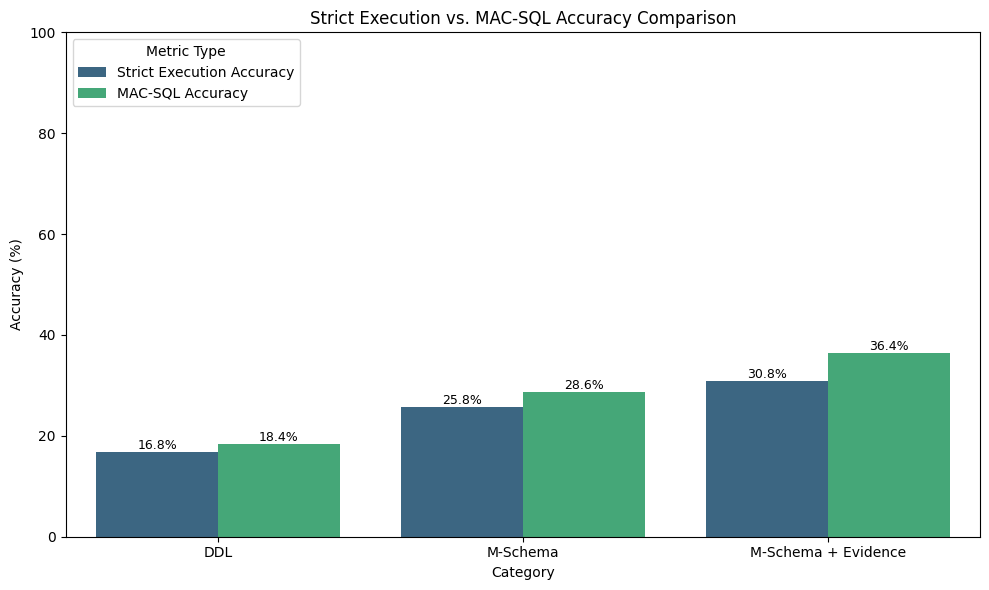

In [13]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

def load_macsql_metrics(path, label):
    with open(path, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    return {
        'Strict Execution Accuracy': metrics[label]['strict_execution']['pct'],
        'MAC-SQL Accuracy': metrics[label]['macsql_execution']['pct']
    }

# Define paths to metrics files
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")

ddl_metrics_path = base_path / "scoring_ddl" / "metrics.json"
mschema_metrics_path = base_path / "scoring_mschema" / "metrics.json"
mschema_evidence_metrics_path = base_path / "scoring_mschema_evidence" / "metrics.json"

# Load metrics
ddl_metrics = load_macsql_metrics(ddl_metrics_path, 'milestone4_frozen')
mschema_metrics = load_macsql_metrics(mschema_metrics_path, 'milestone4_frozen_mschema')
mschema_evidence_metrics = load_macsql_metrics(mschema_evidence_metrics_path, 'milestone4_frozen_evidence')

# Prepare data for plotting
data = {
    'Category': ['DDL', 'DDL', 'M-Schema', 'M-Schema', 'M-Schema + Evidence', 'M-Schema + Evidence'],
    'Metric Type': ['Strict Execution Accuracy', 'MAC-SQL Accuracy', 'Strict Execution Accuracy', 'MAC-SQL Accuracy', 'Strict Execution Accuracy', 'MAC-SQL Accuracy'],
    'Accuracy': [
        ddl_metrics['Strict Execution Accuracy'], ddl_metrics['MAC-SQL Accuracy'],
        mschema_metrics['Strict Execution Accuracy'], mschema_metrics['MAC-SQL Accuracy'],
        mschema_evidence_metrics['Strict Execution Accuracy'], mschema_evidence_metrics['MAC-SQL Accuracy'],
    ]
}
df = pd.DataFrame(data)

# Create the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Accuracy', hue='Metric Type', data=df, palette='viridis')

plt.title('Strict Execution vs. MAC-SQL Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend(title='Metric Type', loc='upper left')

# Add value labels on top of bars
for container in plt.gca().containers:
    for patch in container.patches:
        plt.text(patch.get_x() + patch.get_width() / 2., patch.get_height(),
                 f'{patch.get_height():.1f}%', ha="center", va="bottom", fontsize=9)

plt.tight_layout()

output_fig_dir = base_path / "figures"
output_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_fig_dir / "milestone5_strict_vs_macsql_accuracy_comparison_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

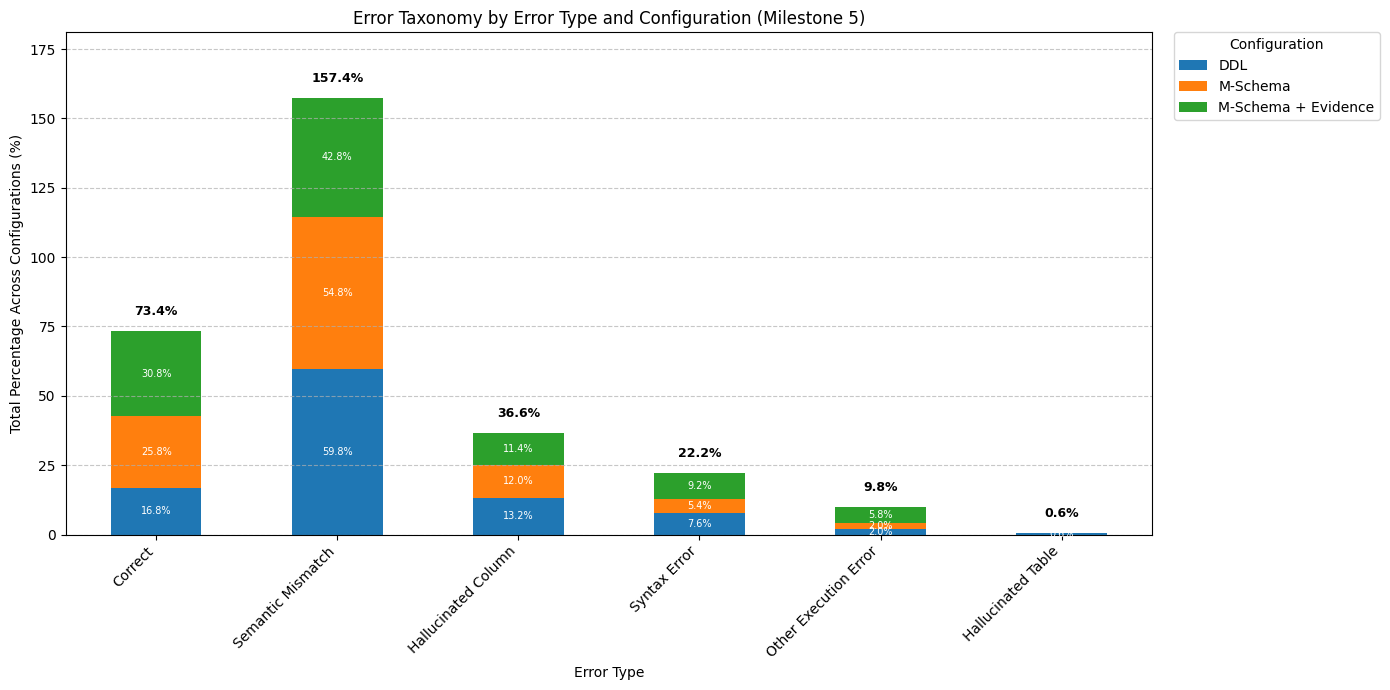

In [16]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

# Define paths to taxonomy summary files
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")

ddl_taxonomy_path = base_path / "evaluation_ddl" / "error_taxonomy_summary.json"
mschema_taxonomy_path = base_path / "evaluation_mschema" / "error_taxonomy_summary_mschema.json"
mschema_evidence_taxonomy_path = base_path / "evaluation_mschema_evidence" / "error_taxonomy_summary_mschema_evidence.json"

# Consistent colors and labels from plot_milestone5_charts
CATEGORY_COLORS = {
    "correct": "#2E7D32",
    "semantic_mismatch": "#EF6C00",
    "hallucinated_column": "#C62828",
    "syntax_error": "#8E24AA",
    "other_execution_error": "#546E7A",
    "hallucinated_table": "#AD1457",
}
CATEGORY_LABELS = {
    "correct": "Correct",
    "semantic_mismatch": "Semantic Mismatch",
    "hallucinated_column": "Hallucinated Column",
    "syntax_error": "Syntax Error",
    "other_execution_error": "Other Execution Error",
    "hallucinated_table": "Hallucinated Table",
}

def load_and_process_taxonomy(path, config_label):
    with open(path, 'r', encoding='utf-8') as f:
        taxonomy = json.load(f)
    pct = taxonomy['error_taxonomy_pct']
    data_rows = []
    for error_type, percentage in pct.items():
        data_rows.append({
            'Configuration': config_label,
            'Error Type': CATEGORY_LABELS.get(error_type, error_type),
            'Percentage': percentage
        })
    return data_rows

# Load data for each configuration
ddl_data = load_and_process_taxonomy(ddl_taxonomy_path, 'DDL')
mschema_data = load_and_process_taxonomy(mschema_taxonomy_path, 'M-Schema')
mschema_evidence_data = load_and_process_taxonomy(mschema_evidence_taxonomy_path, 'M-Schema + Evidence')

# Combine all data into a single DataFrame
all_data = ddl_data + mschema_data + mschema_evidence_data
df_taxonomy = pd.DataFrame(all_data)

# Pivot to create the structure for stacked bar chart: Error Type on x-axis, Configurations stacked
df_for_plotting = df_taxonomy.pivot_table(index='Error Type', columns='Configuration', values='Percentage').fillna(0)

# Define a consistent order for error types on the x-axis
error_type_order = [
    CATEGORY_LABELS['correct'],
    CATEGORY_LABELS['semantic_mismatch'],
    CATEGORY_LABELS['hallucinated_column'],
    CATEGORY_LABELS['syntax_error'],
    CATEGORY_LABELS['other_execution_error'],
    CATEGORY_LABELS['hallucinated_table']
]
# Filter out any error types that might not be present in the current data after pivoting
error_type_order_filtered = [et for et in error_type_order if et in df_for_plotting.index]
df_for_plotting = df_for_plotting.reindex(error_type_order_filtered)

# Define colors for the stacked configurations
config_colors = {
    'DDL': '#1f77b4', # blue
    'M-Schema': '#ff7f0e', # orange
    'M-Schema + Evidence': '#2ca02c' # green
}
# Ensure the color order matches the column order of df_for_plotting
colors_for_stacks = [config_colors[col] for col in df_for_plotting.columns]

# Create the stacked bar chart
plt.figure(figsize=(14, 7))
ax = df_for_plotting.plot(kind='bar', stacked=True, color=colors_for_stacks, ax=plt.gca())

plt.title('Error Taxonomy by Error Type and Configuration (Milestone 5)')
plt.ylabel('Total Percentage Across Configurations (%)')
plt.xlabel('Error Type')
plt.xticks(rotation=45, ha='right') # Rotate for readability

# Set y-axis limit based on max total height + a buffer
max_y = df_for_plotting.sum(axis=1).max()
plt.ylim(0, max_y * 1.15)

# Add value labels for each segment (if significant) and total labels on top of bars
for c in ax.containers:
    labels = []
    for v in c.datavalues:
        if v > 0.1: # Only label if value is significant enough to show clearly
            labels.append(f'{v:.1f}%')
        else:
            labels.append('')
    ax.bar_label(c, labels=labels, label_type='center', fontsize=7, color='white')

# Add total sum labels on top of each stacked bar
for i, total_height in enumerate(df_for_plotting.sum(axis=1)):
    ax.text(i, total_height + max_y * 0.03, f'{total_height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(title='Configuration', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for readability

plt.tight_layout()

output_fig_dir = base_path / "figures"
output_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_fig_dir / "milestone5_error_taxonomy_error_type_stacked_by_config.png", dpi=150, bbox_inches="tight")
plt.show()

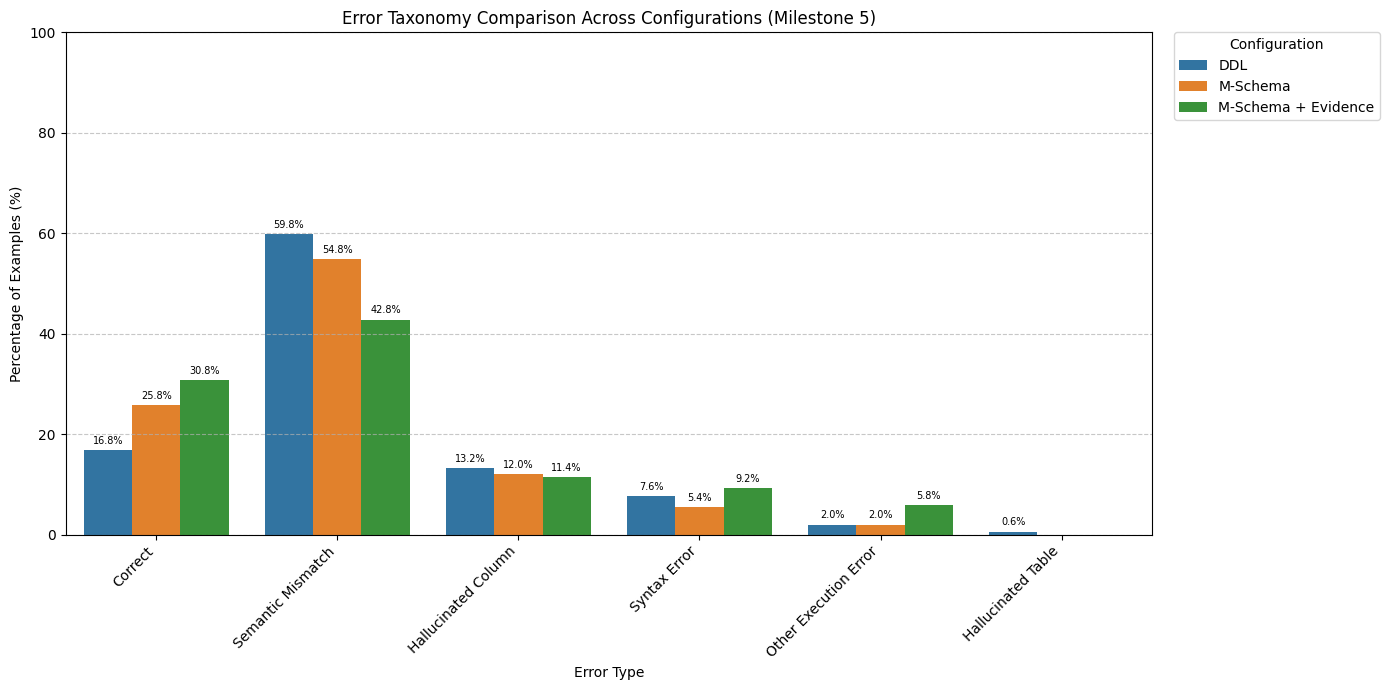

In [17]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

# Define paths to taxonomy summary files
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")

ddl_taxonomy_path = base_path / "evaluation_ddl" / "error_taxonomy_summary.json"
mschema_taxonomy_path = base_path / "evaluation_mschema" / "error_taxonomy_summary_mschema.json"
mschema_evidence_taxonomy_path = base_path / "evaluation_mschema_evidence" / "error_taxonomy_summary_mschema_evidence.json"

# Consistent colors and labels
CATEGORY_COLORS = {
    "correct": "#2E7D32",
    "semantic_mismatch": "#EF6C00",
    "hallucinated_column": "#C62828",
    "syntax_error": "#8E24AA",
    "other_execution_error": "#546E7A",
    "hallucinated_table": "#AD1457",
}
CATEGORY_LABELS = {
    "correct": "Correct",
    "semantic_mismatch": "Semantic Mismatch",
    "hallucinated_column": "Hallucinated Column",
    "syntax_error": "Syntax Error",
    "other_execution_error": "Other Execution Error",
    "hallucinated_table": "Hallucinated Table",
}

def load_and_process_taxonomy(path, config_label):
    with open(path, 'r', encoding='utf-8') as f:
        taxonomy = json.load(f)
    pct = taxonomy['error_taxonomy_pct']
    data_rows = []
    for error_type, percentage in pct.items():
        data_rows.append({
            'Configuration': config_label,
            'Error Type': CATEGORY_LABELS.get(error_type, error_type),
            'Percentage': percentage
        })
    return data_rows

# Load data for each configuration
ddl_data = load_and_process_taxonomy(ddl_taxonomy_path, 'DDL')
mschema_data = load_and_process_taxonomy(mschema_taxonomy_path, 'M-Schema')
mschema_evidence_data = load_and_process_taxonomy(mschema_evidence_taxonomy_path, 'M-Schema + Evidence')

# Combine all data into a single DataFrame
all_data = ddl_data + mschema_data + mschema_evidence_data
df_taxonomy = pd.DataFrame(all_data)

# Define a consistent order for error types on the x-axis
error_type_order = [
    CATEGORY_LABELS['correct'],
    CATEGORY_LABELS['semantic_mismatch'],
    CATEGORY_LABELS['hallucinated_column'],
    CATEGORY_LABELS['syntax_error'],
    CATEGORY_LABELS['other_execution_error'],
    CATEGORY_LABELS['hallucinated_table']
]

# Convert 'Error Type' to a categorical type with defined order for consistent plotting
df_taxonomy['Error Type'] = pd.Categorical(df_taxonomy['Error Type'], categories=error_type_order, ordered=True)

# Define colors for the configurations
config_palette = {
    'DDL': '#1f77b4', # blue
    'M-Schema': '#ff7f0e', # orange
    'M-Schema + Evidence': '#2ca02c' # green
}

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Error Type', y='Percentage', hue='Configuration', data=df_taxonomy, palette=config_palette)

plt.title('Error Taxonomy Comparison Across Configurations (Milestone 5)')
plt.ylabel('Percentage of Examples (%)')
plt.xlabel('Error Type')
plt.xticks(rotation=45, ha='right') # Rotate for readability
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=7, padding=3)

plt.legend(title='Configuration', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for readability

plt.tight_layout()

output_fig_dir = base_path / "figures"
output_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_fig_dir / "milestone5_error_taxonomy_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

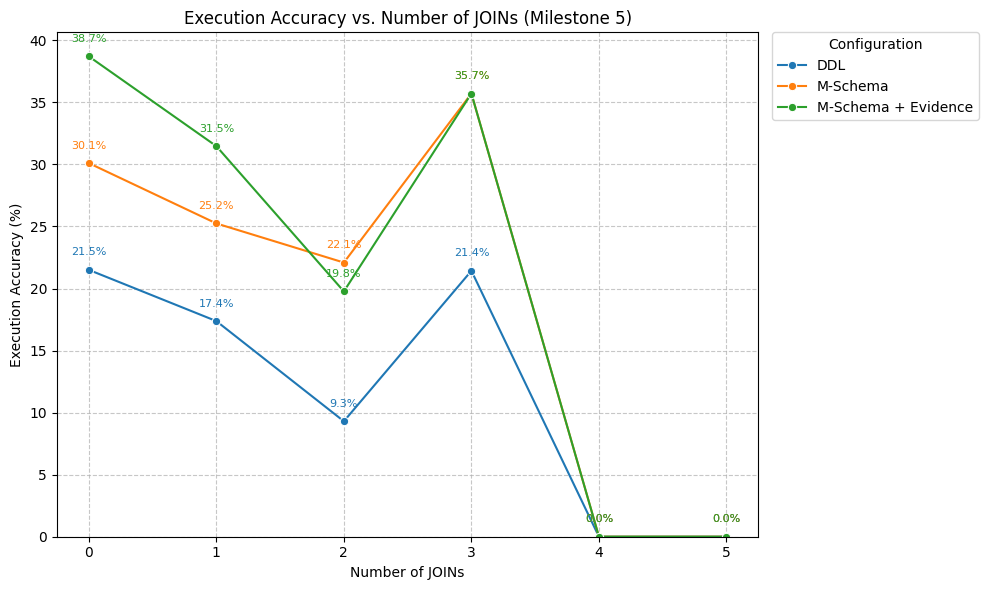

In [5]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

# Define paths to taxonomy summary files
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")

ddl_taxonomy_path = base_path / "evaluation_ddl" / "error_taxonomy_summary.json"
mschema_taxonomy_path = base_path / "evaluation_mschema" / "error_taxonomy_summary_mschema.json"
mschema_evidence_taxonomy_path = base_path / "evaluation_mschema_evidence" / "error_taxonomy_summary_mschema_evidence.json"

def load_join_accuracy(path, config_label):
    if not path.exists():
        print(f"Error: Taxonomy summary file not found for {config_label}: {path}")
        return []
    with open(path, 'r', encoding='utf-8') as f:
        taxonomy = json.load(f)
    join_accuracy_data = []
    # Ensure 'accuracy_by_join_count' exists and is not empty
    if 'accuracy_by_join_count' in taxonomy and taxonomy['accuracy_by_join_count']:
        for num_joins_str, accuracy_val in taxonomy['accuracy_by_join_count'].items():
            join_accuracy_data.append({
                'Configuration': config_label,
                'Num_Joins': int(num_joins_str),
                'Execution_Accuracy': accuracy_val * 100 # Convert to percentage
            })
    else:
        print(f"Warning: 'accuracy_by_join_count' not found or empty in {config_label} taxonomy summary: {path}")
    return join_accuracy_data

# Load data for each configuration
ddl_join_accuracy = load_join_accuracy(ddl_taxonomy_path, 'DDL')
mschema_join_accuracy = load_join_accuracy(mschema_taxonomy_path, 'M-Schema')
mschema_evidence_join_accuracy = load_join_accuracy(mschema_evidence_taxonomy_path, 'M-Schema + Evidence')

# Combine all data into a single DataFrame
all_join_accuracy_data = ddl_join_accuracy + mschema_join_accuracy + mschema_evidence_join_accuracy

if not all_join_accuracy_data:
    print("No data available to plot. Please ensure all error taxonomy summary files are generated correctly.")
else:
    df_join_accuracy = pd.DataFrame(all_join_accuracy_data)

    # Sort by number of joins for proper line plotting
    df_join_accuracy = df_join_accuracy.sort_values(by=['Configuration', 'Num_Joins'])

    # Define colors for the configurations
    config_palette = {
        'DDL': '#1f77b4', # blue
        'M-Schema': '#ff7f0e', # orange
        'M-Schema + Evidence': '#2ca02c' # green
    }

    # Create the line plot
    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(
        x='Num_Joins',
        y='Execution_Accuracy',
        hue='Configuration',
        data=df_join_accuracy,
        marker='o',
        palette=config_palette
    )

    plt.title('Execution Accuracy vs. Number of JOINs (Milestone 5)')
    plt.ylabel('Execution Accuracy (%)')
    plt.xlabel('Number of JOINs')

    # Ensure unique join counts are shown on x-axis, handling cases where df might be empty
    if not df_join_accuracy['Num_Joins'].empty:
        plt.xticks(df_join_accuracy['Num_Joins'].unique())

    plt.ylim(bottom=0) # Start y-axis from 0

    # Add labels to points
    for config in df_join_accuracy['Configuration'].unique():
        subset = df_join_accuracy[df_join_accuracy['Configuration'] == config]
        for i, row in subset.iterrows():
            ax.text(row['Num_Joins'], row['Execution_Accuracy'] + 1, # Offset label slightly above point
                    f'{row["Execution_Accuracy"]:.1f}%',
                    color=config_palette[config], ha='center', va='bottom', fontsize=8)

    plt.legend(title='Configuration', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()

    output_fig_dir = base_path / "figures"
    output_fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_fig_dir / "milestone5_accuracy_vs_joins_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

### Detailed Analysis of Queries by Number of JOINs

Let's inspect some example queries for 1, 2, and 3 JOINs to understand the model's performance characteristics. We'll use the predictions from the 'M-Schema + Evidence' configuration, which exhibited a higher accuracy at 3 joins than 2 joins.

METRICS TABLE
 JOIN count   n Subquery rate  Mean gold SQL tokens  Mean question tokens
          1 305         10.2%                  30.2                  16.6
          2  86         12.8%                  38.6                  15.7
          3  14         14.3%                  47.9                  14.6

Table saved to: /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/figures/join_count_metrics_table.csv


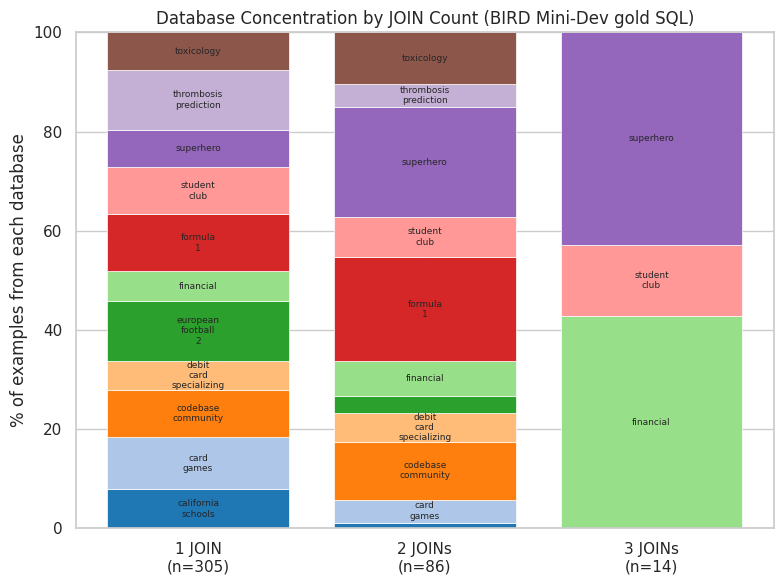


Chart saved to: /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5/figures/milestone5_db_concentration_by_joins.png


In [14]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.0)

# ------------------------------------------------------------
# 1. Load predictions and compute join count / subquery / token stats
#    directly from gold_sql -- same approach as error_taxonomy_analysis.py
# ------------------------------------------------------------
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")
predictions_path = base_path / "evaluation_mschema" / "milestone4_frozen" / "predictions.jsonl"

rows = [json.loads(l) for l in open(predictions_path, encoding="utf-8")]
df = pd.DataFrame(rows)

JOIN_RE = re.compile(r"\bJOIN\b", re.IGNORECASE)
SUBQUERY_RE = re.compile(r"\(\s*SELECT\b", re.IGNORECASE)

df["gold_num_joins"] = df["gold_sql"].apply(lambda s: len(JOIN_RE.findall(s)))
df["has_subquery"] = df["gold_sql"].apply(lambda s: bool(SUBQUERY_RE.search(s)))
df["sql_tokens"] = df["gold_sql"].apply(lambda s: len(s.split()))
df["question_tokens"] = df["question"].apply(lambda q: len(q.split()))

# ------------------------------------------------------------
# 2. Build the metrics table (n, subquery rate, mean tokens) for 1-3 joins
# ------------------------------------------------------------
join_counts_to_analyze = [1, 2, 3]
summary_rows = []
db_distributions = {}

for n in join_counts_to_analyze:
    subset = df[df["gold_num_joins"] == n]
    summary_rows.append({
        "JOIN count": n,
        "n": len(subset),
        "Subquery rate": f"{subset['has_subquery'].mean():.1%}",
        "Mean gold SQL tokens": round(subset["sql_tokens"].mean(), 1),
        "Mean question tokens": round(subset["question_tokens"].mean(), 1),
    })
    db_distributions[n] = subset["db_id"].value_counts().to_dict()

summary_table = pd.DataFrame(summary_rows)
print("=" * 60)
print("METRICS TABLE")
print("=" * 60)
print(summary_table.to_string(index=False))

# Save as CSV too, for easy copy into the report
output_dir = base_path / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
summary_table.to_csv(output_dir / "join_count_metrics_table.csv", index=False)
print(f"\nTable saved to: {output_dir / 'join_count_metrics_table.csv'}")

# ------------------------------------------------------------
# 3. Database concentration chart (100% stacked bar per join count)
# ------------------------------------------------------------
all_dbs = sorted(set(db for dist in db_distributions.values() for db in dist.keys()))
palette = sns.color_palette("tab20", len(all_dbs))
db_colors = dict(zip(all_dbs, palette))

fig, ax = plt.subplots(figsize=(8, 6))

for i, n in enumerate(join_counts_to_analyze):
    dist = db_distributions[n]
    total = sum(dist.values())
    bottom = 0
    for db in all_dbs:
        count = dist.get(db, 0)
        if count == 0:
            continue
        pct = count / total * 100
        ax.bar(i, pct, bottom=bottom, color=db_colors[db], edgecolor="white", linewidth=0.5)
        if pct > 4:  # only label segments large enough to read
            ax.text(i, bottom + pct / 2, db.replace("_", "\n"), ha="center", va="center", fontsize=6.5)
        bottom += pct

ax.set_xticks(range(len(join_counts_to_analyze)))
ax.set_xticklabels([f"{n} JOIN{'s' if n != 1 else ''}\n(n={len(df[df['gold_num_joins']==n])})"
                     for n in join_counts_to_analyze])
ax.set_ylabel("% of examples from each database")
ax.set_title("Database Concentration by JOIN Count (BIRD Mini-Dev gold SQL)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(output_dir / "milestone5_db_concentration_by_joins.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nChart saved to: {output_dir / 'milestone5_db_concentration_by_joins.png'}")

The apparent accuracy increase observed at 3 JOINs (Section 10.2, Figure 6) is not evidence that 3-JOIN queries are genuinely easier than 1- or 2-JOIN queries. Instead, it is an artifact of how the 14 three-JOIN examples happen to be distributed across databases.

As shown in Figure X, the 1-JOIN subset (n=305) draws fairly evenly from all 11 BIRD Mini-Dev databases. The 3-JOIN subset (n=14), by contrast, comes almost entirely from just two databases — superhero and financial account for roughly 85% of these examples, with student_club making up the rest. This matters because the reported "3-JOIN accuracy" is therefore mostly measuring how well checkpoint 375 performs on these two specific database schemas, not how well it handles three-way joins in general.

This is not explained by the 3-JOIN questions being simpler in other ways: they have the longest gold SQL of any JOIN-count group (47.9 tokens on average) and the highest subquery rate (14.3%), so if anything they look more complex, not less. The most likely explanation is that checkpoint 375 happens to perform well on the superhero and financial schemas specifically, and this database-level effect appears in the chart as a join-count effect purely by coincidence of which questions BIRD assigned three joins to.

For the same reason, the 4- and 5-JOIN datapoints should not be read as meaningful trends at all — each is based on a single example (n=1), so the result is simply whether that one query happened to be right or wrong, not a real accuracy rate.

In [17]:
import json
import re
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Load predictions
# ------------------------------------------------------------
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")
predictions_path = base_path / "evaluation_mschema" / "milestone4_frozen" / "predictions.jsonl"

rows = [json.loads(l) for l in open(predictions_path, encoding="utf-8")]
df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Compute structural features from gold SQL
# ------------------------------------------------------------
JOIN_RE = re.compile(r"\bJOIN\b", re.IGNORECASE)
GROUP_BY_RE = re.compile(r"\bGROUP\s+BY\b", re.IGNORECASE)
SUBQUERY_RE = re.compile(r"\(\s*SELECT\b", re.IGNORECASE)

df["num_joins"] = df["gold_sql"].apply(lambda s: len(JOIN_RE.findall(s)))
df["has_join"] = df["num_joins"] >= 1
df["multiple_joins"] = df["num_joins"] >= 2
df["has_group_by"] = df["gold_sql"].apply(lambda s: bool(GROUP_BY_RE.search(s)))
df["has_subquery"] = df["gold_sql"].apply(lambda s: bool(SUBQUERY_RE.search(s)))
df["sql_tokens"] = df["gold_sql"].apply(lambda s: len(s.split()))
df["long_sql"] = df["sql_tokens"] > 31

# ------------------------------------------------------------
# Categorize each prediction's error type (same logic as
# error_taxonomy_analysis.py)
# ------------------------------------------------------------
NO_SUCH_COLUMN = re.compile(r"no such column:\s*([\w.\"]+)", re.IGNORECASE)
NO_SUCH_TABLE = re.compile(r"no such table:\s*([\w.\"]+)", re.IGNORECASE)

def categorize(row):
    if row["execution_match"]:
        return "correct"
    if not row.get("syntax_valid", True):
        return "syntax_error"
    error = row.get("prediction_execution_error")
    if not isinstance(error, str):
        error = ""
    if NO_SUCH_COLUMN.search(error):
        return "hallucinated_column"
    if NO_SUCH_TABLE.search(error):
        return "hallucinated_table"
    if row.get("prediction_execution_status") == "ok":
        return "semantic_mismatch"
    return "other_execution_error"

df["category"] = df.apply(categorize, axis=1)

# ------------------------------------------------------------
# For each feature, compare error-type distribution WITH vs WITHOUT
# -- this directly tests whether the claimed mechanism shows up as
# the predicted error type, not just "accuracy is lower"
# ------------------------------------------------------------
features_to_test = {
    "has_join": "Any JOIN -> predicted mechanism: hallucinated_column (wrong FK relationships)",
    "multiple_joins": "Multiple JOINs -> predicted mechanism: hallucinated_column, more severe than single JOIN",
    "has_group_by": "GROUP BY -> predicted mechanism: other_execution_error (aggregate misuse)",
    "has_subquery": "Subqueries -> predicted mechanism: semantic_mismatch (multi-level reasoning)",
    "long_sql": "Long SQL -> predicted mechanism: syntax_error (compounding generation errors)",
}

for feature, hypothesis in features_to_test.items():
    print("=" * 70)
    print(hypothesis)
    print("=" * 70)
    crosstab = pd.crosstab(df[feature], df["category"], normalize="index") * 100
    crosstab = crosstab.round(1)
    print(crosstab)
    print()

Any JOIN -> predicted mechanism: hallucinated_column (wrong FK relationships)
category  correct  hallucinated_column  other_execution_error  \
has_join                                                        
False        30.1                  4.3                    3.2   
True         24.8                 13.8                    1.7   

category  semantic_mismatch  syntax_error  
has_join                                   
False                  53.8           8.6  
True                   55.0           4.7  

Multiple JOINs -> predicted mechanism: hallucinated_column, more severe than single JOIN
category        correct  hallucinated_column  other_execution_error  \
multiple_joins                                                        
False              26.4                 11.8                    2.0   
True               23.5                 12.7                    2.0   

category        semantic_mismatch  syntax_error  
multiple_joins                                   
False     

In [20]:
import json
import re
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Load predictions
# ------------------------------------------------------------
base_path = Path("/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project/evidence/milestone5")
predictions_path = base_path / "evaluation_mschema" / "milestone4_frozen" / "predictions.jsonl"

rows = [json.loads(l) for l in open(predictions_path, encoding="utf-8")]
df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Compute structural features from gold SQL
# ------------------------------------------------------------
JOIN_RE = re.compile(r"\bJOIN\b", re.IGNORECASE)
GROUP_BY_RE = re.compile(r"\bGROUP\s+BY\b", re.IGNORECASE)
SUBQUERY_RE = re.compile(r"\(\s*SELECT\b", re.IGNORECASE)

df["num_joins"] = df["gold_sql"].apply(lambda s: len(JOIN_RE.findall(s)))
df["has_join"] = df["num_joins"] >= 1
df["multiple_joins"] = df["num_joins"] >= 2
df["has_group_by"] = df["gold_sql"].apply(lambda s: bool(GROUP_BY_RE.search(s)))
df["has_subquery"] = df["gold_sql"].apply(lambda s: bool(SUBQUERY_RE.search(s)))
df["sql_tokens"] = df["gold_sql"].apply(lambda s: len(s.split()))
df["long_sql"] = df["sql_tokens"] > 31

# ------------------------------------------------------------
# Categorize each prediction's error type
# ------------------------------------------------------------
NO_SUCH_COLUMN = re.compile(r"no such column:\s*([\w.\"]+)", re.IGNORECASE)
NO_SUCH_TABLE = re.compile(r"no such table:\s*([\w.\"]+)", re.IGNORECASE)

def categorize(row):
    if row["execution_match"]:
        return "correct"
    if not row.get("syntax_valid", True):
        return "syntax_error"
    error = row.get("prediction_execution_error")
    if not isinstance(error, str):
        error = ""
    if NO_SUCH_COLUMN.search(error):
        return "hallucinated_column"
    if NO_SUCH_TABLE.search(error):
        return "hallucinated_table"
    if row.get("prediction_execution_status") == "ok":
        return "semantic_mismatch"
    return "other_execution_error"

df["category"] = df.apply(categorize, axis=1)

# ------------------------------------------------------------
# Build ONE combined readable table: rows = feature x (with/without),
# columns = error categories, plus a "predicted mechanism" label
# ------------------------------------------------------------
TABLE_TITLE = "Error Category Distribution by SQL Feature: Testing Predicted Failure Mechanisms"

features = {
    "has_join":       ("Any JOIN", "hallucinated_column"),
    "multiple_joins": ("Multiple JOINs", "hallucinated_column"),
    "has_group_by":   ("GROUP BY", "other_execution_error"),
    "has_subquery":   ("Subqueries", "semantic_mismatch"),
    "long_sql":       ("Long SQL (>31 tok)", "syntax_error"),
}

category_order = ["correct", "hallucinated_column", "other_execution_error", "semantic_mismatch", "syntax_error"]

summary_rows = []
for col, (label, predicted_mechanism) in features.items():
    for present in [False, True]:
        subset = df[df[col] == present]
        pct = (subset["category"].value_counts(normalize=True) * 100).reindex(category_order, fill_value=0).round(1)
        row = {
            "Feature": label,
            "Predicted mechanism": predicted_mechanism if present else "",
            "Group": "With" if present else "Without",
            "n": len(subset),
        }
        row.update(pct.to_dict())
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Nice column order and display
display_cols = ["Feature", "Group", "n", "correct", "hallucinated_column",
                 "other_execution_error", "semantic_mismatch", "syntax_error", "Predicted mechanism"]
summary_df = summary_df[display_cols]

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 25)

print("=" * len(TABLE_TITLE))
print(TABLE_TITLE)
print("=" * len(TABLE_TITLE))
print(summary_df.to_string(index=False))

# Save as CSV for easy import into the report
output_dir = base_path / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(output_dir / "milestone5_feature_error_breakdown_table.csv", index=False)
print(f"\nSaved to: {output_dir / 'milestone5_feature_error_breakdown_table.csv'}")

# ------------------------------------------------------------
# Also render as a styled HTML table (much easier to read in Colab
# than the plain-text version above)
# ------------------------------------------------------------
def highlight_predicted(row):
    styles = [""] * len(row)
    mechanism = row["Predicted mechanism"]
    if mechanism and mechanism in display_cols:
        idx = display_cols.index(mechanism)
        styles[idx] = "background-color: #ffe0b2; font-weight: bold"
    return styles

styled = summary_df.style.apply(highlight_predicted, axis=1).format(precision=1)
styled

Error Category Distribution by SQL Feature: Testing Predicted Failure Mechanisms
           Feature   Group   n  correct  hallucinated_column  other_execution_error  semantic_mismatch  syntax_error   Predicted mechanism
          Any JOIN Without  93     30.1                  4.3                    3.2               53.8           8.6                      
          Any JOIN    With 407     24.8                 13.8                    1.7               55.0           4.7   hallucinated_column
    Multiple JOINs Without 398     26.4                 11.8                    2.0               53.5           6.3                      
    Multiple JOINs    With 102     23.5                 12.7                    2.0               59.8           2.0   hallucinated_column
          GROUP BY Without 445     27.0                 11.2                    1.8               53.9           6.1                      
          GROUP BY    With  55     16.4                 18.2                    3.6  

,Feature,Group,n,correct,hallucinated_column,other_execution_error,semantic_mismatch,syntax_error,Predicted mechanism
0,Any JOIN,Without,93,30.1,4.3,3.2,53.8,8.6,
1,Any JOIN,With,407,24.8,13.8,1.7,55.0,4.7,hallucinated_column
2,Multiple JOINs,Without,398,26.4,11.8,2.0,53.5,6.3,
3,Multiple JOINs,With,102,23.5,12.7,2.0,59.8,2.0,hallucinated_column
4,GROUP BY,Without,445,27.0,11.2,1.8,53.9,6.1,
5,GROUP BY,With,55,16.4,18.2,3.6,61.8,0.0,other_execution_error
6,Subqueries,Without,437,27.7,11.7,1.6,53.8,5.3,
7,Subqueries,With,63,12.7,14.3,4.8,61.9,6.3,semantic_mismatch
8,Long SQL (>31 tok),Without,311,32.8,9.3,2.3,51.4,4.2,
9,Long SQL (>31 tok),With,189,14.3,16.4,1.6,60.3,7.4,syntax_error



**Table X. Error category distribution by SQL structural feature — M-Schema configuration (primary, n=500)**, with vs. without each feature present, alongside the specific failure mechanism each feature was hypothesized to cause.

This table tests, rather than assumes, the causal explanations proposed for feature-conditioned accuracy degradation under the M-Schema (training-matched) prompt configuration (Section 10.2). For each feature, the "Without" row shows the error-category breakdown for gold-SQL examples lacking that feature, and the "With" row shows the same breakdown for examples that have it, both computed from the M-Schema run's predictions. If a hypothesized mechanism is correct, the predicted error category (right-most column) should show the largest increase between the two rows.

**Any JOIN** is the clearest confirmed case under M-Schema: hallucinated-column errors rise from 4.3% to 13.8% — a 3.2x increase, and the single largest shift observed anywhere in the table. This directly supports the hypothesis that JOIN queries fail primarily because the model assigns a column to the wrong table.

**Multiple JOINs**, however, does not show a further increase in hallucinated-column errors (11.8% → 12.7%, essentially flat) — the confusion-across-tables effect appears to saturate at the presence of any JOIN rather than compounding with additional JOINs. Instead, semantic mismatch grows further (53.5% → 59.8%).

**GROUP BY**'s predicted mechanism (aggregate misuse) does increase (1.8% → 3.6%), but accounts for only a small share of GROUP BY's 10.6-point accuracy drop under this configuration; hallucinated-column and semantic mismatch explain substantially more.

**Subqueries** show a real increase in semantic mismatch as predicted (53.8% → 61.9%), but the predicted mechanism is present, not dominant, in the M-Schema run.

**Long SQL**'s predicted mechanism (syntax_error) shows only a modest increase (4.2% → 7.4%); hallucinated-column rises by nearly twice as much.

**Summary (M-Schema configuration only)**: of the five hypothesized mechanisms, only the JOIN → hallucinated-column relationship is strongly and specifically confirmed. This analysis has not yet been repeated for the DDL or M-Schema+evidence configurations — the pattern may differ under those prompt formats and should not be assumed to generalize without separate verification.

---

The added "M-Schema configuration only" framing (in the title, method description, and closing summary) makes clear this is one specific run's finding, not a claim about checkpoint 375 in general — consistent with how the rest of your report already distinguishes between the three configurations.

### Latency and VRAM

In [21]:
!cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project && python src/scripts/summarize_latency_vram.py \
  --predictions evidence/milestone5/evaluation_mschema/milestone4_frozen/predictions.jsonl \
  --metrics evidence/milestone5/evaluation_mschema/milestone4_frozen/metrics.json \
  --run-label "M-Schema (primary)" \
  --output-json evidence/milestone5/latency_vram_summary.json

[M-Schema (primary)] 500 predictions, 500 with latency recorded

LATENCY (ms per example, batched generation)
  mean:    2517.5 ms
  median:  2205.8 ms
  min:     982.4 ms
  max:     7878.3 ms
  stdev:   1339.5 ms
  total generation time (sum): 1258.8 s (21.0 min)

PEAK GPU MEMORY (from metrics.json cuda_peak)
  allocated_gib: 7.62 GiB
  reserved_gib: 16.99 GiB
  max_allocated_gib: 13.08 GiB
  max_reserved_gib: 21.74 GiB
  final_batch_size: 8
  attention: sdpa
  dtype: torch.bfloat16
  load_seconds: 11.971
  evaluation_seconds: 1245.763

Summary written to: evidence/milestone5/latency_vram_summary.json


Latency: each batch of 8 examples takes an average of 2.5 seconds to generate (2517.5 ms), with real variability (median 2.2s, up to 7.9s for the slowest batch — likely longer schemas or longer gold-length questions requiring more generation tokens). Total generation time for all 500 examples was 21 minutes — fast in absolute terms, meaning inference cost is not a barrier to this system being used interactively.

Peak GPU memory: the model actually used 13.08 GiB (max_allocated_gib) at its peak, but PyTorch reserved 21.74 GiB (max_reserved_gib) from the GPU — this gap is normal caching behavior, not a leak. Practically: this configuration needs a GPU with at least ~22 GiB VRAM to run safely without hitting out-of-memory errors, which matches your L4 (22.03 GiB total) almost exactly — you were running close to the edge of what that specific GPU can handle at batch size 8.

What this tells you for the report:

Inference is cheap and fast — 21 minutes for 500 examples (~2.5s/batch-of-8, roughly 0.3s/example) means this could plausibly run in a real interactive analytics-copilot setting without noticeable user-facing delay, especially if batch size were reduced to 1 for single-query latency.
Memory is the binding constraint, not speed — at batch size 8, you're using almost the entirety of the L4's 22 GiB. This is directly relevant to Section 12 (Computational Performance) and your deployment discussion (Section 16.2): a smaller GPU (e.g., a T4 at 15-16 GiB) would likely need a smaller batch size to run this same configuration without OOM.




In [26]:
%cd /content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project
!git status

/content/drive/MyDrive/Group-10-DS-and-AI-Lab-Project
Refresh index: 100% (273/273), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   output/figures/tables_per_db.png
	modified:   src/scripts/build_qwen3_hparam_screen.py
	modified:   src/scripts/build_qwen3_hparam_split.py
	modified:   src/scripts/make_qwen3_hparam_config.py
	modified:   src/scripts/run_colab_qlora_hparam.sh
	modified:   src/scripts/run_colab_zero_shot_eval.sh

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	evidence/milestone5/
	src/scripts/analyze_eval_results.py
	src/scripts/download_bird_minidev.py
	src/scripts/error_taxonomy_analysis.py
	src/scripts/prepare_bird_eval.py
	src/scripts/prepare_bird_mschema_eval.py
	src/scripts/repair_hallucinated_columns.py
	src/scripts/schema_linking_preci